# 🏥 MedShare: Federated Learning for Survival Analysis

> **Mode**: Full Scientific Run (Complete Dataset)
>
> **Kernel**: Ensure the top right shows **Google Colab**
>
> **Runtime**: Python 3 with GPU (optional, works on CPU too)

---

## 📋 Execution Flow

1. **Setup** - Mount Drive, Install Dependencies, Deploy Blockchain
2. **Experiments** - Run MI, DP, Robustness, Latency tests
3. **Visualization** - Generate and display all 5 plots

**Estimated Total Time**: 15-25 minutes

---

In [6]:
## 📁 1. Google Drive Sync & Project Setup
from google.colab import drive
import os

print("Mounting Google Drive...")
os.chdir('/content')
drive.mount('/content/drive', force_remount=True)

# Update this path to match your Google Drive structure
PROJECT_PATH = '/content/drive/Othercomputers/My laptop/bxp267'

if os.path.exists(PROJECT_PATH):
    try:
        %cd "$PROJECT_PATH"
        print(f"✅ Project directory: {os.getcwd()}")

        # Clean old results for fresh run
        # !rm -f test/*.csv test/*.png  <-- COMMENTED OUT TO PREVENT DATA LOSS
        print("🚀 Ready for scientific run (Resume enabled).")
    except Exception as e:
        print(f"❌ Error: {e}")
else:
    print(f"❌ Path not found: {PROJECT_PATH}")
    print("Please update PROJECT_PATH to match your Google Drive structure.")

Mounting Google Drive...
Mounted at /content/drive
/content/drive/Othercomputers/My laptop/bxp267
✅ Project directory: /content/drive/Othercomputers/My laptop/bxp267
🚀 Ready for scientific run (Resume enabled).


In [2]:
## 🛠️ 2. Environment Setup
print("Installing dependencies (this may take 2-3 minutes)...\n")

# Install Python dependencies
import torch
use_gpu = torch.cuda.is_available()
if not use_gpu:
    !pip install -q "protobuf<6" "cryptography<44" "flwr[simulation]" opacus ucimlrepo web3 kagglehub imbalanced-learn
else:
    !pip install -q "protobuf<6" "cryptography<44" "flwr[simulation]" opacus ucimlrepo web3 kagglehub imbalanced-learn

# Install Ganache (blockchain simulator)
!npm install -g ganache --legacy-peer-deps 2>&1 | tail -1

print("\n" + "="*70)
print("🔍 Verifying Critical Imports...")
print("="*70 + "\n")

try:
    import flwr
    print(f"✅ flwr version: {flwr.__version__}")
except ImportError as e: print(f"❌ flwr failed: {e}")

try:
    import torch
    print(f"✅ torch version: {torch.__version__} (GPU: {torch.cuda.is_available()})")
except ImportError as e: print(f"❌ torch failed: {e}")

try:
    import opacus
    print(f"✅ opacus version: {opacus.__version__}")
except ImportError as e: print(f"❌ opacus failed: {e}")

try:
    from web3 import Web3
    # Web3 v7+ removed __version__, we use importlib.metadata or just report 'installed'
    import importlib.metadata
    try:
        w3_v = importlib.metadata.version('web3')
        print(f"✅ web3 version: {w3_v}")
    except:
        print("✅ web3: installed")
except ImportError as e: print(f"❌ web3 failed: {e}")

import os, subprocess, time, json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("\n" + "="*70)
print("✅ Environment setup complete.")
print("="*70)


Installing dependencies (this may take 2-3 minutes)...

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.7/66.7 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 587.5/587.5 kB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 110.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.4/51.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.7/251.7 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 531.7/531.7 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.3/340.3 kB 36.5 MB/s

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


✅ web3 version: 7.14.1

✅ Environment setup complete.


/usr/local/lib/python3.12/dist-packages/websockets/legacy/__init__.py:6: DeprecationWarning: websockets.legacy is deprecated; see https://websockets.readthedocs.io/en/stable/howto/upgrade.html for upgrade instructions
  warnings.warn(  # deprecated in 14.0 - 2024-11-09


In [3]:
## 🚀 3. Blockchain Infrastructure
import socket, time, subprocess, os, json, urllib.request

RPC_PORT = "8545"

print(f"Cleaning up port {RPC_PORT}...")
!lsof -ti:$RPC_PORT | xargs kill -9 > /dev/null 2>&1
time.sleep(2)

print(f"Starting Ganache on port {RPC_PORT}...")
subprocess.Popen(
    ["ganache", "--port", RPC_PORT, "--miner.blockGasLimit", "0xffffffffffff", "--wallet.defaultBalance", "100"],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(5)  # Wait for Ganache to start

print("Deploying smart contracts...")
!python scripts/deploy_colab.py

print("\n✅ Blockchain infrastructure ready.")

Cleaning up port 8545...
Starting Ganache on port 8545...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Deploying smart contracts...
Connecting to local blockchain...
✅ Connected to Ganache on port 8545
Deploying from: 0x34c8508dAA7c3FaFb6a4D50bcc1B28b1ed7C4a87
Deploying MedShareTask...
[Success] MedShareTask deployed to: 0xA501FDA5F20999112e870C7DD688985eeb39cd69
Deploying CommitmentRegistry...
[Success] CommitmentRegistry deployed to: 0x8d6450FDdE3fc903ee03464461Becf2aA2A16f26
Deploying Reputation...
[Success] Reputation deployed to: 0x7c93e21F6CBacC50AE1F1326667C4D23a5331A78

[Success] Deployment summary saved to build/deploy_info.json

✅ Blockchain infrastructure ready.


In [4]:
## 🔍 Pre-Experiment System Check
import sys
import importlib

print("="*70)
print("🔍 PRE-EXPERIMENT SYSTEM CHECK")
print("="*70 + "\n")

# Critical modules check
critical_modules = ['flwr', 'torch', 'opacus', 'web3']
all_ok = True

for module_name in critical_modules:
    try:
        module = importlib.import_module(module_name)
        version = getattr(module, '__version__', 'unknown')
        print(f"✅ {module_name}: {version}")
    except ImportError:
        print(f"❌ {module_name}: NOT FOUND")
        all_ok = False

# Check file structure
print("\n📁 Checking Project Files:\n")

required_files = [
    'federated_survival.py',
    'test/plot_results.py',
    'scripts/deploy_colab.py',
    'medshare/client.py',
    'medshare/engine.py'
]

for file_path in required_files:
    if os.path.exists(file_path):
        print(f"✅ {file_path}")
    else:
        print(f"❌ {file_path} (missing)")
        all_ok = False

print("\n" + "="*70)
if all_ok:
    print("✅ ALL PRE-CHECKS PASSED - Ready to run experiments!")
else:
    print("❌ PRE-CHECK FAILED - Please fix issues above before proceeding.")
    print("\nCommon fixes:")
    print("  - For missing modules: Restart runtime and re-run setup cell")
    print("  - For missing files: Check Google Drive sync and PROJECT_PATH")
print("="*70)

🔍 PRE-EXPERIMENT SYSTEM CHECK

✅ flwr: 1.15.2
✅ torch: 2.9.0+cu128
✅ opacus: 1.5.4
✅ web3: 7.14.1

📁 Checking Project Files:

✅ federated_survival.py
✅ test/plot_results.py
✅ scripts/deploy_colab.py
✅ medshare/client.py
✅ medshare/engine.py

✅ ALL PRE-CHECKS PASSED - Ready to run experiments!


In [7]:
## 🧪 4. Master Experiment Sweep (Optimized for GPU)
import os
print("\n" + "="*70)
print("🔬 RUNNING MI EXPERIMENT (Whole Dataset, optimized for Hardware)")
print("="*70 + "\n")

# Run with optimized batch size and parallelism
!python federated_survival.py \
    --experiment mi \
    --dataset support2_disease \
    --rounds 20 \
    --epochs 25 \
    --enable_dp True \
    --enable_blockchain True

print(f"\n{'='*70}")
print("✅ MI EXPERIMENT COMPLETE")
print(f"{'='*70}")



🔬 RUNNING MI EXPERIMENT (Whole Dataset, optimized for Hardware)

2026-02-11 02:46:49.474223: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770778009.494598    5247 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770778009.501328    5247 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770778009.519687    5247 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770778009.519711    5247 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:177077800

In [ ]:
## 🔍 4. High-Intensity Privacy Audit (Leakage Baseline)
print("="*70)
print("🚀 RUNNING HIGH-INTENSITY PRIVACY AUDIT")
print("Objective: Force overfitting to observe baseline leakage (No Privacy)")
print("="*70 + "\n")

# Run with 10 rounds and 10 local epochs to simulate high-intensity attack
!python federated_survival.py --dataset support2 --rounds 10 --epochs 10 --experiment mi

print("\n✅ Audit Complete. Check 'exp_mi_results.csv' for detailed leakage vs noise analysis.")

In [ ]:
## ✅ 5. Verify Generated Data Files
import os

csv_files = [
    "test/exp_dp_results.csv",
    "test/exp_mi_results.csv",
    "test/exp_robustness_results.csv",
    "test/exp_gas_log.csv",
    "test/exp_latency_log.csv"
]

print("\n📊 Data Files Status:\n" + "="*50)
found = 0
for f in csv_files:
    if os.path.exists(f):
        size = os.path.getsize(f)
        print(f"✅ {f} ({size:,} bytes)")
        found += 1
    else:
        print(f"❌ {f} (missing)")

print(f"\n📈 Found {found}/5 data files")

if found == 5:
    print("\n🎉 All data files generated successfully!")
else:
    print(f"\n⚠️ Warning: {5-found} data file(s) missing. Some plots may not generate.")

In [8]:
## 📊 6. Generate All Plots
print("Generating scientific visualization plots...\n")

if os.path.exists("test/plot_results.py"):
    !python test/plot_results.py
else:
    print("❌ plot_results.py not found!")

# Verify generated plots
plot_files = [
    "test/fig_mi.png",
    "test/fig_dp_tradeoff.png",
    "test/fig_robustness.png",
    "test/fig_gas_costs.png",
    "test/fig_latency.png"
]

print("\n📊 Generated Plots:\n" + "="*50)
generated = 0
for plot in plot_files:
    if os.path.exists(plot):
        size = os.path.getsize(plot)
        print(f"✅ {plot} ({size:,} bytes)")
        generated += 1
    else:
        print(f"❌ {plot} (not generated)")

print(f"\n📈 Generated {generated}/5 plots")

Generating scientific visualization plots...

Working directory set to: /content/drive/Othercomputers/My laptop/bxp267/test
--- Attempting to plot fig_dp_tradeoff.png ---
DEBUG: Checking for DP results at: /content/drive/Othercomputers/My laptop/bxp267/test/exp_dp_results.csv
DEBUG: Directory contents: ['best_model.pth', 'centralized_SUPPORT2_500.json', 'centralized_SUPPORT2_1000.json', 'centralized_Stroke_2000.json', 'centralized_Stroke_100.json', 'centralized_SUPPORT2_100.json', 'centralized_Admin-Billing-Risk_100.json', 'centralized_Admin-Condition_100.json', 'centralized_Admin-Category_200.json', 'centralized_Stroke_200.json', 'centralized_Maternal-Health_1000.json', 'centralized_Maternal-Health_500.json', 'centralized_Admin-Billing-Risk_1000.json', 'centralized_Admin-Category_1000.json', 'centralized_Admin-Category_500.json', 'centralized_Admin-Category_100.json', 'centralized_SUPPORT2-Death_1000.json', 'centralized_Stroke_1000.json', 'centralized_SUPPORT2-DiseaseGroup_1000.json',

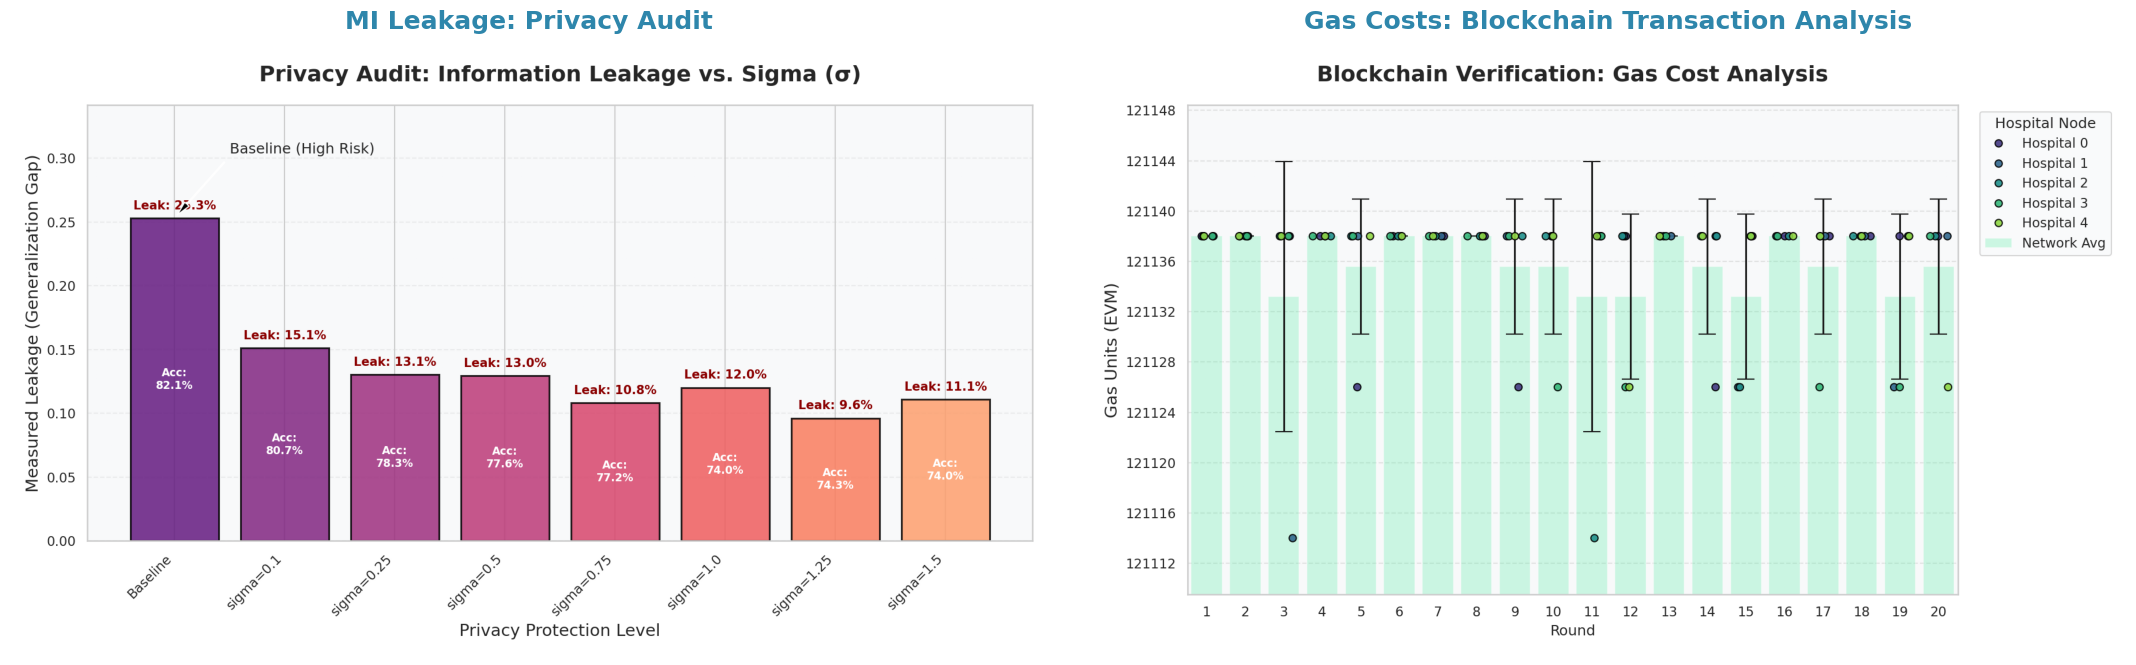


🎉 Successfully displayed 2/5 plots!


In [9]:
## 🖼️ 7. Display All Scientific Plots
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

plots = [
    "test/fig_mi.png",
    "test/fig_dp_tradeoff.png",
    "test/fig_robustness.png",
    "test/fig_gas_costs.png",
    "test/fig_latency.png"
]

plot_titles = [
    "MI Leakage: Privacy Audit",
    "DP Tradeoff: Privacy vs Accuracy",
    "Robustness: Byzantine Attack Mitigation",
    "Gas Costs: Blockchain Transaction Analysis",
    "Latency: Round-to-Round Communication"
]

existing_plots = [(p, t) for p, t in zip(plots, plot_titles) if os.path.exists(p)]

if existing_plots:
    cols = 2
    rows = (len(existing_plots) + 1) // 2
    plt.figure(figsize=(22, 9 * rows))

    for i, (path, title) in enumerate(existing_plots):
        plt.subplot(rows, cols, i+1)
        img = mpimg.imread(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(title, fontsize=18, fontweight='bold', pad=15, color='#2E86AB')

    plt.tight_layout(pad=3.0)
    plt.show()

    print(f"\n🎉 Successfully displayed {len(existing_plots)}/5 plots!")
else:
    print("❌ No plots found!")
    print("\nPlease run the experiment sweep first (Cell 4).")

In [ ]:
## 📋 8. Execution Summary Report
import os
import json

print("="*70)
print("📊 MEDSHARE EXECUTION SUMMARY")
print("="*70)

# Check data files
csv_files = [
    "test/exp_dp_results.csv",
    "test/exp_mi_results.csv",
    "test/exp_robustness_results.csv",
    "test/exp_gas_log.csv",
    "test/exp_latency_log.csv"
]

csv_count = sum(1 for f in csv_files if os.path.exists(f))

# Check plots
plot_files = [
    "test/fig_mi.png",
    "test/fig_dp_tradeoff.png",
    "test/fig_robustness.png",
    "test/fig_gas_costs.png",
    "test/fig_latency.png"
]

plot_count = sum(1 for f in plot_files if os.path.exists(f))

print(f"\n📁 Data Files: {csv_count}/5 generated")
print(f"📊 Plots: {plot_count}/5 generated")

# Check for comparison stats
if os.path.exists("comparison_stats.json"):
    with open("comparison_stats.json", "r") as f:
        stats = json.load(f)
    print(f"\n🎯 Final Global Accuracy: {stats.get('global_accuracy', 'N/A')}")
    print(f"🔐 Privacy Budget (ε): {stats.get('epsilon', 'N/A')}")
    print(f"⛓️ Blockchain Enabled: {stats.get('blockchain_enabled', 'N/A')}")

print("\n" + "="*70)

if csv_count == 5 and plot_count == 5:
    print("✅ FULL EXECUTION COMPLETE - ALL TESTS PASSED")
else:
    print(f"⚠️ PARTIAL EXECUTION - {5-csv_count} data files and {5-plot_count} plots missing")

print("="*70)